<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/pendulum_detachment_momentum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rate of Change of Total Angular Momentum in Free-Flight for each detached pendulum

<>:87: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\c'
<>:87: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2324/1929224852.py:87: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("Rate of Change of Total Angular Momentum in Free-Flight\n$dL_{total}/dt = -mg \cdot x_{cm}(t)$",
/tmp/ipykernel_2324/1929224852.py:90: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Rate of Change of Angular Momentum $dL_{total}/dt$ (kg$\cdot$m$^2$/s$^2$)", fontsize=12)


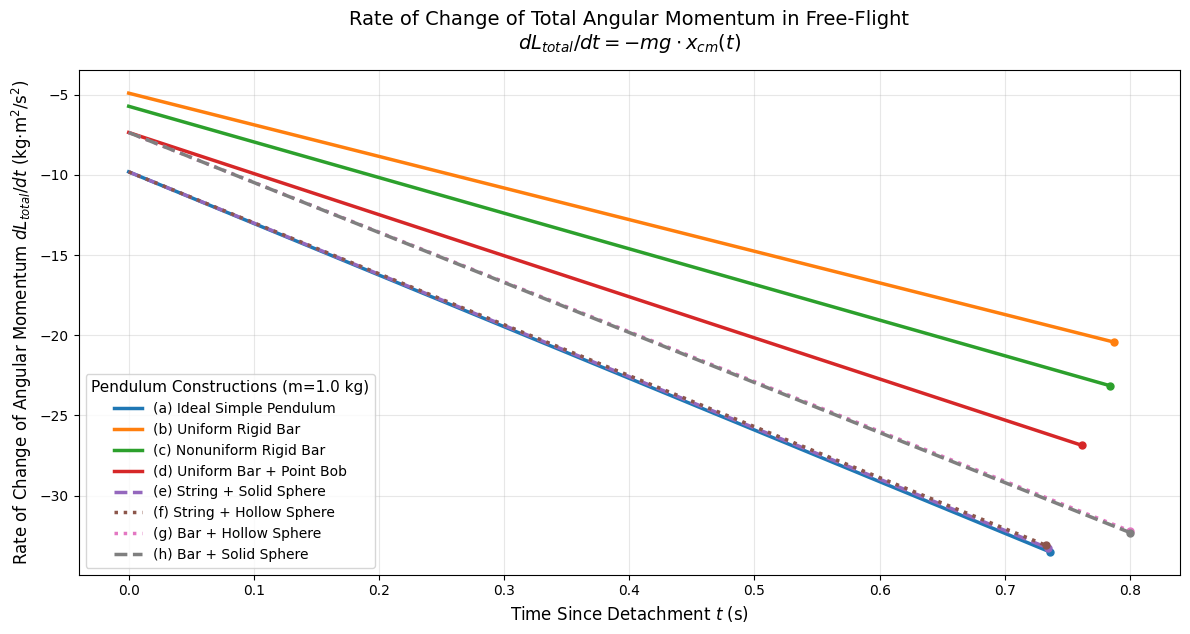

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Physical Parameters & Setup
# ==========================================
g = 9.81        # Gravity (m/s^2)
l = 2.0         # Length of pendulum string/rod (m)
R = 0.4         # Radius of the spherical bobs (m)
m = 1.0         # Total mass of the pendulum (kg) - assumed 1.0 for the plot

# Release from -60 degrees, detach at +30 degrees
theta_0 = np.radians(-60)
theta_f = np.radians(30)
delta_cos = np.cos(theta_f) - np.cos(theta_0)

# Time array for the free-flight projectile motion
# 0.8s is long enough to ensure all configurations hit the floor
t = np.linspace(0, 0.8, 500)
floor_y = -l - 1.0

# ==========================================
# 2. Case Definitions
# ==========================================
# Format: 'Label': (r_cm, v_cm, color, line_style)
cases = {}

# (a) Ideal Simple Pendulum (Point Mass)
cases['(a) Ideal Simple Pendulum'] = (l, np.sqrt(2 * g * l * delta_cos), '#1f77b4', '-')

# (b) Uniform Rigid Bar
cases['(b) Uniform Rigid Bar'] = (0.5 * l, 0.5 * np.sqrt(3 * g * l * delta_cos), '#ff7f0e', '-')

# (c) Nonuniform Rigid Bar (r_cm = 7/12 l)
v_cm_c = (7/12) * l * np.sqrt((14 * g) / (5 * l) * delta_cos)
cases['(c) Nonuniform Rigid Bar'] = ((7/12) * l, v_cm_c, '#2ca02c', '-')

# (d) Uniform Bar + Point Bob
cases['(d) Uniform Bar + Point Bob'] = (0.75 * l, (9/8) * np.sqrt(g * l * delta_cos), '#d62728', '-')

# (e) String + Solid Sphere
cases['(e) String + Solid Sphere'] = (l, l * np.sqrt((2 * g * l) / (l**2 + 0.4 * R**2) * delta_cos), '#9467bd', '--')

# (f) String + Hollow Sphere
cases['(f) String + Hollow Sphere'] = (l, l * np.sqrt((2 * g * l) / (l**2 + (2/3) * R**2) * delta_cos), '#8c564b', ':')

# (g) Bar + Hollow Sphere
cases['(g) Bar + Hollow Sphere'] = (0.75 * l, (9/8) * l * np.sqrt((g * l) / ((2/3)*l**2 + (1/3)*R**2) * delta_cos), '#e377c2', ':')

# (h) Bar + Solid Sphere
cases['(h) Bar + Solid Sphere'] = (0.75 * l, (9/8) * l * np.sqrt((g * l) / ((2/3)*l**2 + (1/5)*R**2) * delta_cos), '#7f7f7f', '--')

# ==========================================
# 3. Plotting Logic
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7))

# Iterate through all the cases and plot dL/dt
for label, (r_cm, v_cm, color, style) in cases.items():

    # 3a. Filter time so we only plot while the object is in the air
    y0 = -r_cm * np.cos(theta_f)
    vy0 = v_cm * np.sin(theta_f)
    y = y0 + vy0 * t - 0.5 * g * t**2

    valid_idx = y >= floor_y
    t_valid = t[valid_idx]

    # 3b. Calculate horizontal position x(t) over the valid time
    x0 = r_cm * np.sin(theta_f)
    vx0 = v_cm * np.cos(theta_f)
    x_valid = x0 + vx0 * t_valid

    # 3c. Calculate the rate of change of angular momentum
    # dL/dt = Torque from gravity = -mg * x(t)
    dL_dt = -m * g * x_valid

    # Plot the curve
    ax.plot(t_valid, dL_dt, color=color, linestyle=style, linewidth=2.5, label=label)

    # Mark the end point (floor impact) with a dot
    ax.plot(t_valid[-1], dL_dt[-1], marker='o', color=color, markersize=5)

# ==========================================
# 4. Formatting and Labels
# ==========================================
ax.set_title("Rate of Change of Total Angular Momentum in Free-Flight\n$dL_{total}/dt = -mg \cdot x_{cm}(t)$",
             fontsize=14, pad=15)
ax.set_xlabel("Time Since Detachment $t$ (s)", fontsize=12)
ax.set_ylabel("Rate of Change of Angular Momentum $dL_{total}/dt$ (kg$\cdot$m$^2$/s$^2$)", fontsize=12)

# Set grid and legend
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=10, title="Pendulum Constructions (m=1.0 kg)", title_fontsize=11)

# Adjust layout to fit caption
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Render the plot
plt.show()